# 01 - Análise exploratória dos dados (EDA)

## Contexto do projeto

Um hospital universitário quer um sistema que **apoie** a triagem de exames: destacar os casos que merecem atenção primeiro, para que o médico gaste seu tempo onde ele é mais necessário. Nesta fase, o problema é de **classificação tabular**: a partir de medidas extraídas de um exame, estimar se um tumor de mama é **benigno (B)** ou **maligno (M)**.

> **O modelo não faz diagnóstico.** Ele sinaliza risco; o médico tem sempre a palavra final.

## Como o projeto está organizado

| Notebook	| Pergunta que responde |
|---|---|
| **01 – EDA** (este) |	Como são os dados? Precisam de limpeza? Quais medidas parecem separar benigno de maligno? |
| **02 – Pré-processamento e modelagem** |	Como preparar os dados, treinar e ajustar os modelos e escolher o melhor **sem usar o teste**? |
| **03 – Avaliação e interpretação** | Como o modelo escolhido se sai no teste? Por que ele decide o que decide? Pode ser usado na prática? |

O código que se repete entre notebooks (carregar e dividir os dados, montar os modelos) fica em `src/triagem_mama/`. Os notebooks importam essas funções e se concentram na análise.

## Objetivo deste notebook
1. Conhecer o dataset: origem, colunas e significado clínico de cada medida.
2. Fazer a limpeza (ausentes, duplicatas, valores impossíveis).
3. Analisar estatísticas descritivas, distribuições e correlações.
4. Registrar as decisões que seguem para o notebook 02.


## O dataset
**Breast Cancer Wisconsin (Diagnostic)**: 569 exames, público, licença CC BY 4.0.
Fonte: Wolberg, Mangasarian, Street & Street (1993), UCI Machine Learning Repository, [doi.org/10.24432/C5DW28](doi.org/10.24432/C5DW2B). Também está disponível no [Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data), de onde veio o arquivo `data/raw/data.csv`.

Cada linha é **um exame de punção aspirativa por agulha fina (PAAF)** de um nódulo de mama. A imagem do material coletado foi digitalizada, e um software mediu o contorno dos núcleos das células. O diagnóstico (`diagnosis`) foi confirmado por exames posteriores.

O dataset não tem dados pessoais (nome, idade, etc.); o `id` é só um número de exame.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from triagem_mama.config import ALVO, CORES_CLASSES, NOMES_CLASSES, PASTA_FIGURAS
from triagem_mama.dados import carregar_dados, carregar_dados_brutos

PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 40)

## 1. Carregando a base

Primeiro olhamos o arquivo **exatamente como foi baixado**, sem nenhum tratamento. 

In [2]:
df_bruto = carregar_dados_brutos()
print(f"Linhas: {df_bruto.shape[0]} | Colunas: {df_bruto.shape[1]}")
df_bruto.head()

Linhas: 569 | Colunas: 33


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Tipo, ausentes e valores distintos de cada coluna.
# Mostramos só as colunas que fogem do padrão (as 30 medidas são todas numéricas e completas).
resumo_colunas = pd.DataFrame({
    "tipo": df_bruto.dtypes.astype(str),
    "valores ausentes": df_bruto.isna().sum(),
    "valores distintos": df_bruto.nunique(),
})

print("Quantidade de colunas por tipo:")
print(df_bruto.dtypes.astype(str).value_counts().to_string())

resumo_colunas[(resumo_colunas["tipo"] != "float64") | (resumo_colunas["valores ausentes"] > 0)]

Quantidade de colunas por tipo:
float64    31
int64       1
str         1


,tipo,valores ausentes,valores distintos
id,int64,0,569
diagnosis,str,0,2
Unnamed: 32,float64,569,0


**O que encontramos:**

- **30 colunas numéricas** com as medidas do núcleo, todas completas.
- `id`: número do exame, um valor diferente por linha. Não tem significado clínico, e usá-lo no modelo seria um erro (ele poderia "decorar" exames pelo número).
- `diagnosis`: o **alvo**, com dois valores (B e M).
- `Unnamed: 32`: coluna **totalmente vazia** (569 ausentes). Ela aparece porque cada linha do CSV termina com uma vírgula sobrando, e o pandas cria uma coluna para o "valor" depois dela.

## 2. Limpeza dos dados
A limpeza decidida acima (remover `id` e `Unnamed: 32` ) está na função `carregar_dados()` em `src/triagem_mama/dados.py`, para que os três notebooks **usem exatamente os mesmos dados**. A seguir, conferimos ausentes, duplicatas e valores impossíveis.

In [5]:
df = carregar_dados()
colunas_medidas = df.columns.drop(ALVO)

print(f"Shape antes da limpeza: {df_bruto.shape} -> depois: {df.shape}")
print(f"Valores ausentes: {df.isna().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")
print(f"Valores negativos: {(df[colunas_medidas]< 0).sum().sum()}")

zeros = (df[colunas_medidas] == 0).sum()
linhas_com_zeros = (df[colunas_medidas] == 0).any(axis=1)
print("\nColunas com valores zero:")
print(zeros[zeros > 0].to_string())
print(f"\nLinhas com algum zero: {linhas_com_zeros.sum()} | diagnóstico dessas linhas: "
        f"{df.loc[linhas_com_zeros, ALVO].value_counts().to_dict()}")

Shape antes da limpeza: (569, 33) -> depois: (569, 31)
Valores ausentes: 0
Linhas duplicadas: 0
Valores negativos: 0

Colunas com valores zero:
concavity_mean          13
concave points_mean     13
concavity_se            13
concave points_se       13
concavity_worst         13
concave points_worst    13

Linhas com algum zero: 13 | diagnóstico dessas linhas: {'B': 13}


**Conclusão da limpeza:**
- Não há ausentes, duplicatas nem valores negativos, que seriam impossíveis para medidas de tamanho e forma.
- **Zeros:** 13 exames têm zeros nas 6 colunas de concavidade (`concavity_*` e `concave points_*`). São sempre os mesmos 13 exames, e todos benignos. Um zero aqui significa **contorno sem reentrâncias**, o que é plausível para núcleos benignos. Não é um código de "valor faltando", então os valores foram mantidos.
- Nenhuma linha foi removida: o dataset segue com **569 exames, 30 medidas e o alvo**

## 3. O que cada medida significa

O software mediu **10 características** de cada núcleo:

|Medida	| Significado |	Leitura clínica (simplificada) |
|---|---|---|
| `radius` |	raio: distância média do centro até o contorno | tamanho do núcleo |
| `texture` |	textura: variação dos tons de cinza dentro do núcleo | heterogeneidade do conteúdo |
| `perimeter` |	perímetro do contorno | tamanho
| `area` |	área |	tamanho |
| `smoothness` |	suavidade: variação local do raio ao longo do contorno | contorno liso × irregular |
| `compactness` |	compacidade: perímetro² / área - 1	| quanto a forma foge de um círculo |
| `concavity`	| concavidade: profundidade das reentrâncias do contorno | irregularidade |
| `concave points` |	pontos côncavos: quantidade de reentrâncias | irregularidade |
| `symmetry`| simetria |	forma |
| `fractal_dimension` |	dimensão fractal do contorno | complexidade do contorno |

Cada medida aparece em **3 versões**, resumindo todos os núcleos de uma mesma imagem:
- `_mean`: **média** entre os núcleos;
- ``_se``: **erro padrão**, ou seja, o quanto a medida varia entre os núcleos;
- ``_worst``: média dos **3 piores** (maiores) valores, os núcleos mais alterados.

Na citologia, núcleos **maiores, mais irregulares e mais heterogêneos** são sinais clássicos de malignidade. A EDA vai verificar se os dados mostram isso.

In [6]:
familias_medidas = {
    "Média (_mean)": [c for c in colunas_medidas if c.endswith("_mean")],
    "Erro padrão (_se)": [c for c in colunas_medidas if c.endswith("_se")],
    "Pior valor (_worst)": [c for c in colunas_medidas if c.endswith("_worst")],
}
pd.DataFrame({
    "Quantidade": {nome: len(cols) for nome, cols in familias_medidas.items()},
    "Medidas": {nome: ", ".join(c.rsplit("_", 1)[0] for c in cols) for nome, cols in familias_medidas.items()},
})

,Quantidade,Medidas
Média (_mean),10,"radius, texture, perimeter, area, smoothness, ..."
Erro padrão (_se),10,"radius, texture, perimeter, area, smoothness, ..."
Pior valor (_worst),10,"radius, texture, perimeter, area, smoothness, ..."


## 4. Distribuição do diagnóstico (alvo)

,amostras,proporção
diagnosis,,
Benigno,357,0.627
Maligno,212,0.373


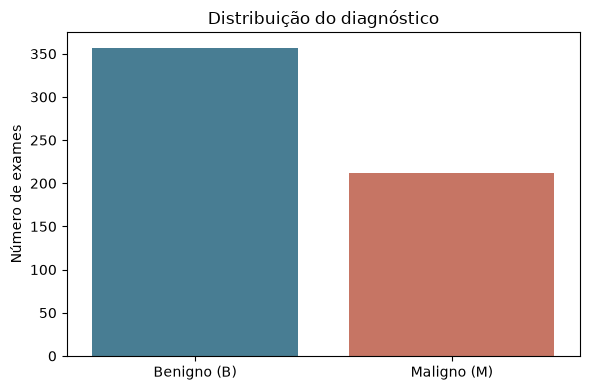

In [7]:
contagem = df[ALVO].value_counts()
display(pd.DataFrame({
    "amostras": contagem,
    "proporção": (contagem / len(df)).round(3),
}).rename(index=NOMES_CLASSES))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x=ALVO, hue=ALVO, order=["B", "M"], hue_order=["B", "M"],
              palette=CORES_CLASSES, legend=False, ax=ax)
ax.set_xticks([0, 1], ["Benigno (B)", "Maligno (M)"])
ax.set_xlabel("")
ax.set_ylabel("Número de exames")
ax.set_title("Distribuição do diagnóstico")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "distribuicao_diagnostico.png", dpi=150)
plt.show()

**Conclusão:** são 357 benignos (62,7%) e 212 malignos (37,3%). O desbalanceamento é **moderado**, mas tem três consequências para as próximas etapas:

- **A acurácia sozinha engana.** Um "modelo" que respondesse sempre "benigno" acertaria 62,7% sem aprender nada. Por isso vamos olhar principalmente o **recall do maligno**: de todos os malignos, quantos o modelo encontrou.
- **Estratificação:** ao dividir em treino, validação e teste, cada parte precisa manter essa mesma proporção (notebook 02).
- Alguns modelos podem favorecer a classe maior. No notebook 02 testamos `class_weight="balanced"`, que dá mais peso aos malignos no treino.

## 5. Estatísticas descritivas

In [8]:
df[colunas_medidas].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture_mean,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter_mean,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area_mean,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness_mean,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness_mean,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
concavity_mean,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
concave points_mean,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
symmetry_mean,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
fractal_dimension_mean,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


**O que a tabela mostra:**

- **As escalas são muito diferentes.** `area_worst` vai de 185 a 4.254, enquanto `smoothness_mean` fica entre 0,05 e 0,16. Modelos baseados em distância (KNN) ou em pesos (Regressão Logística) seriam dominados pelas medidas de números grandes, sem que elas sejam mais importantes. Por isso o pipeline do notebook 02 **padroniza** as medidas (média 0, desvio 1).
- **Assimetria:** em várias medidas a média é bem maior que a mediana (50%), como em `area_mean` (655 × 551). Há alguns exames com valores muito altos, que veremos como outliers nos boxplots.


## 6. Análise de correlação

A **correlação de Pearson** mede o quanto duas medidas variam juntas em linha reta, numa escala de -1 a 1:

- perto de **1**: quando uma sobe, a outra sobe;
- perto de **-1**: quando uma sobe, a outra desce;
- perto de **0**: não há relação linear.

Usamos Pearson porque todas as medidas são contínuas e o objetivo aqui é exploratório. Duas perguntas guiam esta seção:

1. Quais medidas andam junto com o diagnóstico maligno?
2. Quais medidas são **redundantes** entre si, ou seja, carregam quase a mesma informação?

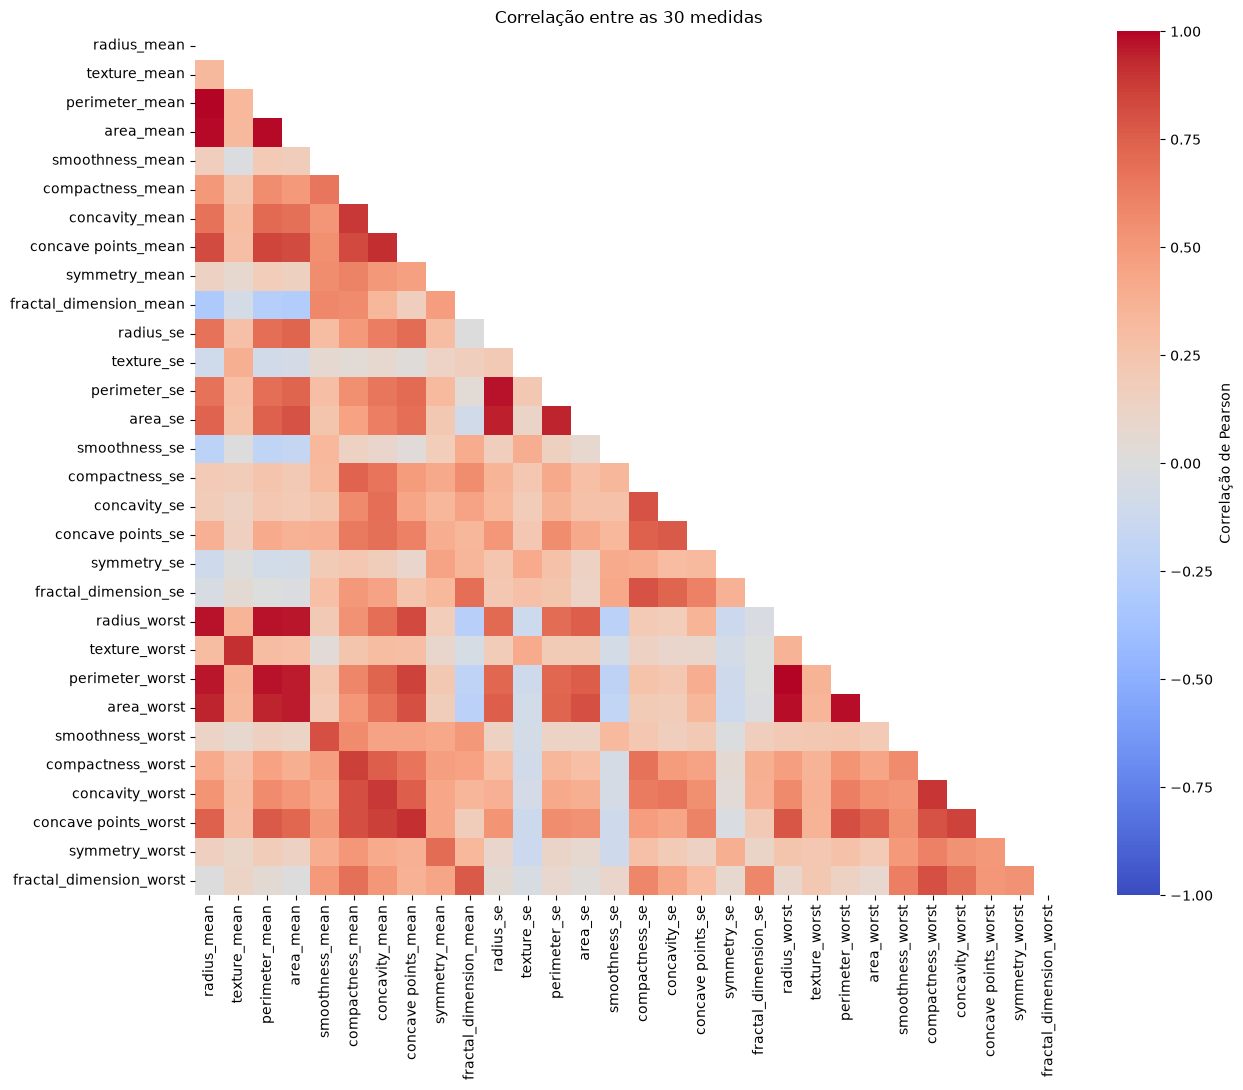

In [9]:
matriz_corr = df[colunas_medidas].corr()
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))  # esconde a metade repetida da matriz

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(matriz_corr, mask=mascara, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            cbar_kws={"label": "Correlação de Pearson"}, ax=ax)
ax.set_title("Correlação entre as 30 medidas")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "matriz_correlacao.png", dpi=150)
plt.show()


### 6.1 Correlação de cada medida com o diagnóstico

Para calcular a correlação com o alvo, codificamos maligno = 1 e benigno = 0. Uma correlação positiva significa que **valores maiores daquela medida aparecem mais nos malignos**.


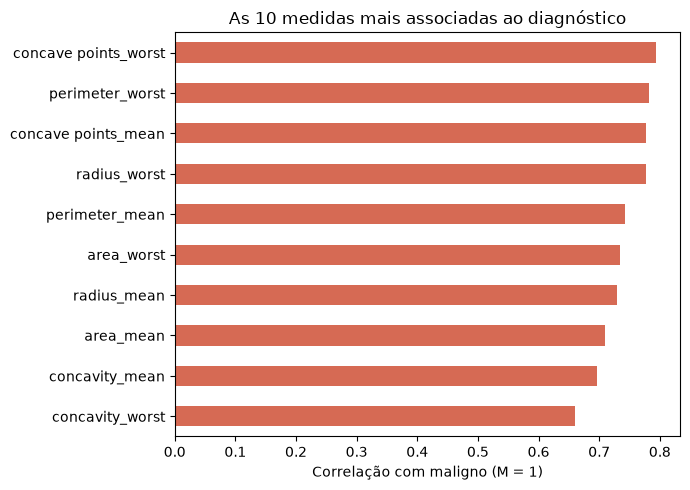

,Mais associadas,r,Menos associadas,r
0,concave points_worst,0.794,fractal_dimension_worst,0.324
1,perimeter_worst,0.783,compactness_se,0.293
2,concave points_mean,0.777,concavity_se,0.254
3,radius_worst,0.776,fractal_dimension_se,0.078
4,perimeter_mean,0.743,smoothness_se,-0.067
5,area_worst,0.734,fractal_dimension_mean,-0.013
6,radius_mean,0.730,texture_se,-0.008
7,area_mean,0.709,symmetry_se,-0.007


In [10]:
y_maligno = (df[ALVO] == "M").astype(int)
corr_alvo = df[colunas_medidas].corrwith(y_maligno).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
corr_alvo.head(10).sort_values().plot.barh(ax=ax, color=CORES_CLASSES["M"])
ax.set_xlabel("Correlação com maligno (M = 1)")
ax.set_title("As 10 medidas mais associadas ao diagnóstico")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "correlacao_alvo.png", dpi=150)
plt.show()

display(pd.DataFrame({
    "Mais associadas": corr_alvo.head(8).round(3).index,
    "r": corr_alvo.head(8).round(3).values,
    "Menos associadas": corr_alvo.tail(8).round(3).index,
    "r ": corr_alvo.tail(8).round(3).values,
}))

**Conclusão:**

- As medidas mais associadas ao maligno são `concave points_worst` (0,794), `perimeter_worst` (0,783), `concave points_mean` (0,777) e `radius_worst` (0,776). Elas descrevem **tamanho** e **irregularidade do contorno**, o que bate com o que a citologia espera de núcleos malignos.
- Várias medidas de **variação** (`_se`) e a dimensão fractal média têm correlação perto de zero. Por exemplo, `symmetry_se` (-0,007) e `texture_se` (-0,008). Sozinhas, quase não diferenciam benigno de maligno.
- **Correlação não é causalidade.** Ela mostra que tamanho e malignidade andam juntos nesta base, não que o tamanho causa a doença. E ela olha uma medida por vez: uma medida fraca sozinha ainda pode ajudar quando combinada com outras.


### 6.2 Medidas redundantes

Calculamos a correlação entre todos os pares de medidas (435 pares únicos) e listamos os mais fortes.

In [11]:
triangulo_superior = matriz_corr.where(np.triu(np.ones(matriz_corr.shape, dtype=bool), k=1))
pares = triangulo_superior.stack().dropna().rename("Correlação").reset_index()
pares.columns = ["Medida A", "Medida B", "Correlação"]
pares["|r|"] = pares["Correlação"].abs()

print(f"Pares analisados: {len(pares)} | pares com |r| >= 0.90: {(pares['|r|'] >= 0.90).sum()}")
pares.nlargest(12, "|r|").drop(columns="|r|").round(3).reset_index(drop=True)


Pares analisados: 435 | pares com |r| >= 0.90: 21


,Medida A,Medida B,Correlação
0,radius_mean,perimeter_mean,0.998
1,radius_worst,perimeter_worst,0.994
2,radius_mean,area_mean,0.987
3,perimeter_mean,area_mean,0.987
4,radius_worst,area_worst,0.984
5,perimeter_worst,area_worst,0.978
6,radius_se,perimeter_se,0.973
7,perimeter_mean,perimeter_worst,0.970
8,radius_mean,radius_worst,0.970
9,perimeter_mean,radius_worst,0.969


**Conclusão:**

- **21 pares** têm correlação ≥ 0,90. Quase todos combinam **raio, perímetro e área**. É geometria: as três medem o tamanho do núcleo (perímetro ≈ 2πr, área ≈ πr²). Exemplo: `radius_mean` × `perimeter_mean` = 0,998.
- A redundância **não atrapalha a previsão**, mas atrapalha a **interpretação** de modelos lineares: a Regressão Logística divide o peso entre medidas quase iguais de forma instável, às vezes com sinais trocados.
- **Decisão:** a EDA sozinha não justifica remover colunas. No notebook 02 testamos, com validação cruzada, uma versão **sem perímetro e área** (só raio) para ver se a redundância faz diferença.


## 7. Distribuições por diagnóstico

Os boxplots comparam benignos e malignos nas 6 medidas mais associadas ao alvo. A caixa vai do 1º ao 3º quartil, a linha do meio é a mediana, e os pontos isolados são valores extremos.

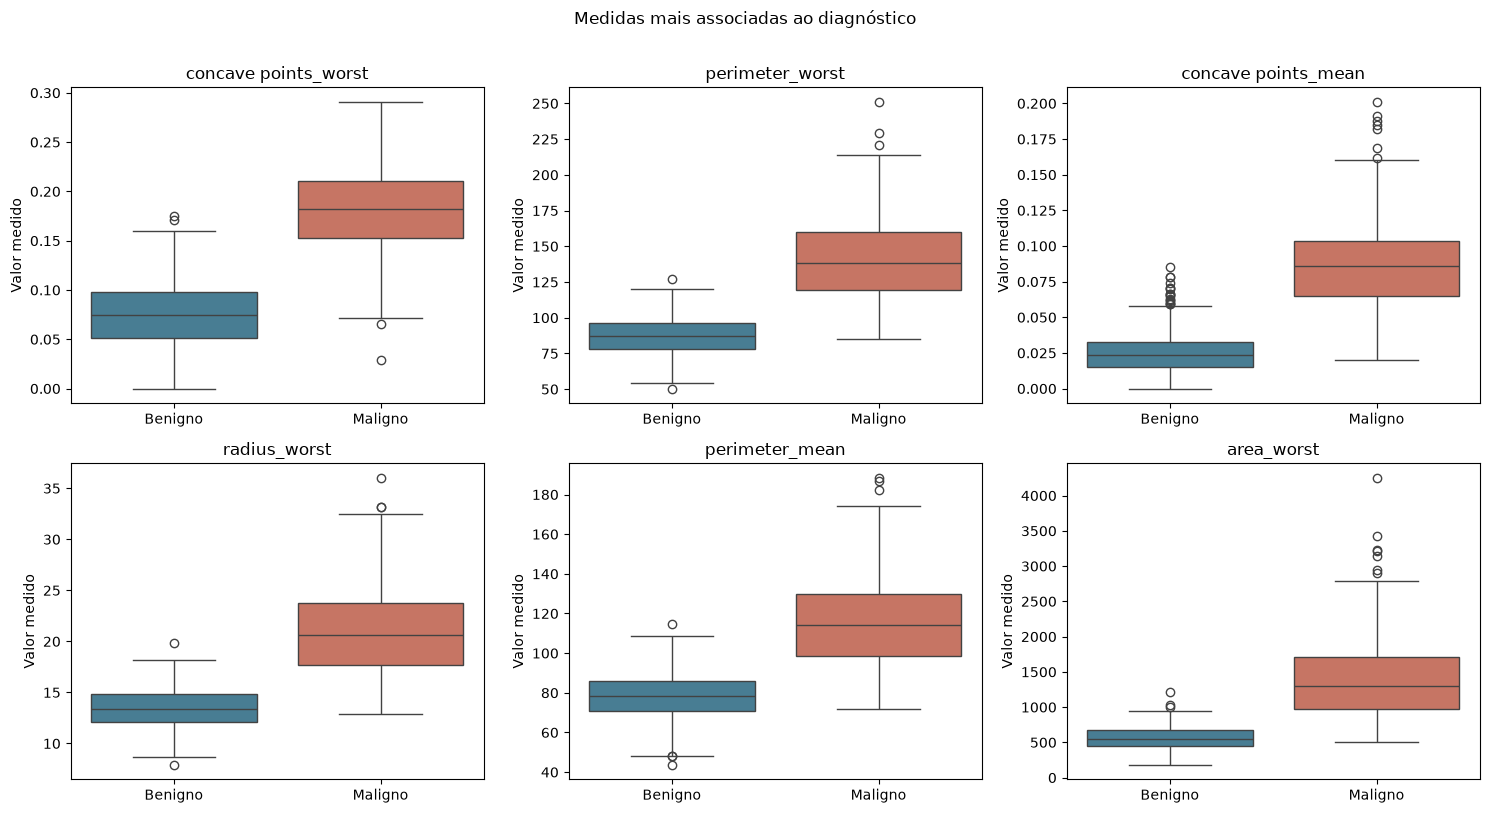

diagnosis,Benigno,Maligno
Mediana,,
concave points_worst,0.074,0.182
perimeter_worst,86.920,138.000
concave points_mean,0.023,0.086
radius_worst,13.350,20.590
perimeter_mean,78.180,114.200
area_worst,547.400,1303.000


In [12]:
features_destaque = corr_alvo.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.flat, features_destaque):
    sns.boxplot(data=df, x=ALVO, y=feature, hue=ALVO, order=["B", "M"], hue_order=["B", "M"],
                palette=CORES_CLASSES, legend=False, ax=ax)
    ax.set_title(feature)
    ax.set_xticks([0, 1], ["Benigno", "Maligno"])
    ax.set_xlabel("")
    ax.set_ylabel("Valor medido")
fig.suptitle("Medidas mais associadas ao diagnóstico", y=1.01)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "boxplots_por_diagnostico.png", dpi=150, bbox_inches="tight")
plt.show()

df.groupby(ALVO)[features_destaque].median().T.rename(columns=NOMES_CLASSES).round(3).rename_axis("Mediana")

**Conclusão:**

- Nos malignos, todas as 6 medidas são **bem maiores**. A mediana de `area_worst` é 1.303 nos malignos contra 547 nos benignos (2,4 vezes). A de `concave points_worst` é 0,182 contra 0,074.
- **Há sobreposição** entre as caixas: alguns benignos grandes, alguns malignos pequenos. Nenhuma medida sozinha separa os grupos perfeitamente, e por isso precisamos de um modelo que **combine várias medidas**.
- Os **outliers** são exames reais com valores extremos, não erros de digitação. Foram mantidos.

## 8. Relações entre pares de medidas

Os gráficos de dispersão mostram duas medidas ao mesmo tempo: uma de **tamanho** (`perimeter_mean`) contra medidas de **textura** e **contorno**. Os pares foram escolhidos para ilustrar, não por busca exaustiva.


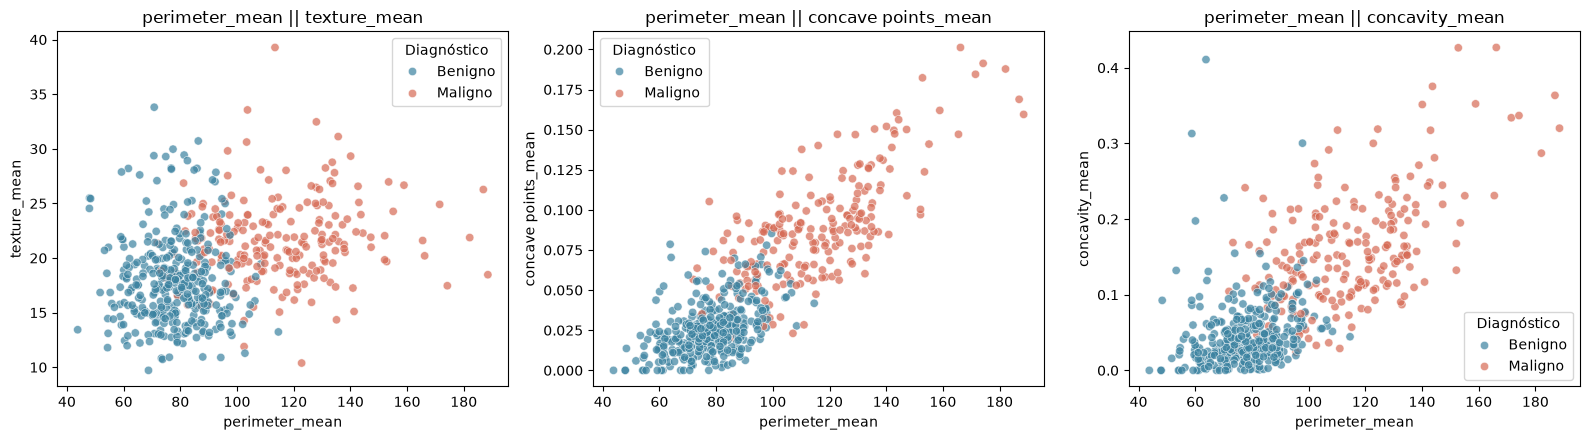

In [14]:
pares_dispersao = [
    ("perimeter_mean", "texture_mean"),
    ("perimeter_mean", "concave points_mean"),
    ("perimeter_mean", "concavity_mean"),
]

# Usamos os nomes por extenso como valores da cor, assim a legenda sai correta sem depender de ordem.
df_grafico = df.assign(Diagnóstico=df[ALVO].map(NOMES_CLASSES))
cores_por_nome = {NOMES_CLASSES[c]: cor for c, cor in CORES_CLASSES.items()}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (fx, fy) in zip(axes, pares_dispersao):
    sns.scatterplot(data=df_grafico, x=fx, y=fy, hue="Diagnóstico", hue_order=["Benigno", "Maligno"],
                    palette=cores_por_nome, alpha=0.7, ax=ax)
    ax.set_title(f"{fx} || {fy}")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "dispersao_pares.png", dpi=150)
plt.show()


**Conclusão:** combinando **tamanho + contorno** (2º e 3º gráficos), as classes ficam visivelmente mais separadas do que com uma medida só: os malignos ocupam a região de perímetro e concavidade altos. Já `texture_mean` separa menos, mas desloca os malignos um pouco para cima. É um indício de que um modelo que **combina medidas** deve funcionar bem, e de que a fronteira entre as classes é razoavelmente simples (quase linear).


# Resumo do notebook 01

| Tema | O que vimos | Decisão para o notebook 02 |
|---|---|---|
| Limpeza | Sem ausentes, duplicatas ou valores impossíveis; `id` e a coluna vazia removidos; zeros plausíveis | Usar `carregar_dados()` (569 × 30 medidas + alvo) |
| Alvo | 62,7% benigno × 37,3% maligno | Split **estratificado**; métrica principal = **recall do maligno**; testar `class_weight="balanced"` |
| Escalas | Medidas com ordens de grandeza muito diferentes | **Padronizar** dentro do pipeline (StandardScaler) |
| Correlação com o alvo | Tamanho e irregularidade do contorno são os mais associados | Manter todas as medidas; o modelo decide como combiná-las |
| Redundância | 21 pares com \|r\| ≥ 0,90 (raio, perímetro, área) | Testar uma versão **sem perímetro e área** |

**Observação sobre vazamento de dados:** esta EDA usou a base inteira só para **descrever** os dados. Nenhum número calculado aqui (médias, correlações) é usado para treinar o modelo. Tudo o que o modelo aprende é calculado no notebook 02, apenas com o conjunto de treino.
